Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, ExtraTreesRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

import warnings
warnings.filterwarnings('ignore')

Загрузка данных

In [2]:
df = pd.read_csv('global_minimum_wage_processed.csv')
print(f"Размер датасета: {df.shape}")

Размер датасета: (186, 26)


Определение признаков и целевой переменной

In [3]:
target = 'Minimum_Wage_USD_Monthly'
exclude_cols = ['Country', 'Currency', 'Wage_Period', 'Notes', target]
feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols]
y = df[target]

print(f"Количество признаков: {X.shape[1]}")

Количество признаков: 21


Удаление пропусков в целевой переменной

In [4]:
mask = y.notna()
X = X[mask]
y = y[mask]
print(f"Объектов после удаления пропусков: {X.shape[0]}")

Объектов после удаления пропусков: 186


Заполнение пропусков в признаках

In [5]:
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
X_imputed = pd.DataFrame(X_imputed, columns=feature_cols)
print(f"Пропуски после заполнения: {X_imputed.isnull().sum().sum()}")

Пропуски после заполнения: 0


Разделение на обучающую и тестовую выборки

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"Обучающая выборка: {X_train.shape[0]} объектов")
print(f"Тестовая выборка: {X_test.shape[0]} объектов")

Обучающая выборка: 148 объектов
Тестовая выборка: 38 объектов


Масштабирование (не обязательно для деревьев, но для единообразия)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Масштабирование выполнено")

Масштабирование выполнено


Обучение модели Bagging

In [8]:
bagging = BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=5), n_estimators=100, random_state=42, n_jobs=-1)
bagging.fit(X_train_scaled, y_train)
y_pred_bagging = bagging.predict(X_test_scaled)

rmse_bagging = np.sqrt(mean_squared_error(y_test, y_pred_bagging))
mae_bagging = mean_absolute_error(y_test, y_pred_bagging)
r2_bagging = r2_score(y_test, y_pred_bagging)

print("BAGGING")
print(f"RMSE: {rmse_bagging:.2f} USD")
print(f"MAE: {mae_bagging:.2f} USD")
print(f"R2: {r2_bagging:.4f}")

BAGGING
RMSE: 492.57 USD
MAE: 298.93 USD
R2: 0.4743


Обучение модели Random Forest

In [9]:
rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("RANDOM FOREST")
print(f"RMSE: {rmse_rf:.2f} USD")
print(f"MAE: {mae_rf:.2f} USD")
print(f"R2: {r2_rf:.4f}")

RANDOM FOREST
RMSE: 492.85 USD
MAE: 299.48 USD
R2: 0.4737


Обучение модели Extra Trees (сверхслучайные деревья)

In [10]:
et = ExtraTreesRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
et.fit(X_train_scaled, y_train)
y_pred_et = et.predict(X_test_scaled)

rmse_et = np.sqrt(mean_squared_error(y_test, y_pred_et))
mae_et = mean_absolute_error(y_test, y_pred_et)
r2_et = r2_score(y_test, y_pred_et)

print("EXTRA TREES")
print(f"RMSE: {rmse_et:.2f} USD")
print(f"MAE: {mae_et:.2f} USD")
print(f"R2: {r2_et:.4f}")

EXTRA TREES
RMSE: 529.11 USD
MAE: 287.28 USD
R2: 0.3934


Обучение модели AdaBoost

In [11]:
ada = AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=3), n_estimators=100, random_state=42)
ada.fit(X_train_scaled, y_train)
y_pred_ada = ada.predict(X_test_scaled)

rmse_ada = np.sqrt(mean_squared_error(y_test, y_pred_ada))
mae_ada = mean_absolute_error(y_test, y_pred_ada)
r2_ada = r2_score(y_test, y_pred_ada)

print("ADABOOST")
print(f"RMSE: {rmse_ada:.2f} USD")
print(f"MAE: {mae_ada:.2f} USD")
print(f"R2: {r2_ada:.4f}")

ADABOOST
RMSE: 430.58 USD
MAE: 290.12 USD
R2: 0.5983


Обучение модели Gradient Boosting

In [12]:
gb = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
gb.fit(X_train_scaled, y_train)
y_pred_gb = gb.predict(X_test_scaled)

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("GRADIENT BOOSTING")
print(f"RMSE: {rmse_gb:.2f} USD")
print(f"MAE: {mae_gb:.2f} USD")
print(f"R2: {r2_gb:.4f}")

GRADIENT BOOSTING
RMSE: 521.26 USD
MAE: 313.53 USD
R2: 0.4113


Сравнение качества моделей

In [13]:
results = pd.DataFrame({
    'Модель': ['Bagging', 'Random Forest', 'Extra Trees', 'AdaBoost', 'Gradient Boosting'],
    'RMSE (USD)': [rmse_bagging, rmse_rf, rmse_et, rmse_ada, rmse_gb],
    'MAE (USD)': [mae_bagging, mae_rf, mae_et, mae_ada, mae_gb],
    'R2': [r2_bagging, r2_rf, r2_et, r2_ada, r2_gb]
})

print(results.to_string(index=False))

best_model = results.loc[results['R2'].idxmax(), 'Модель']
print(f"\nЛучшая модель по R2: {best_model}")

           Модель  RMSE (USD)  MAE (USD)       R2
          Bagging  492.566683 298.929506 0.474325
    Random Forest  492.852511 299.484136 0.473715
      Extra Trees  529.111670 287.275660 0.393428
         AdaBoost  430.582474 290.117464 0.598302
Gradient Boosting  521.257600 313.534944 0.411303

Лучшая модель по R2: AdaBoost


Визуализация сравнения моделей

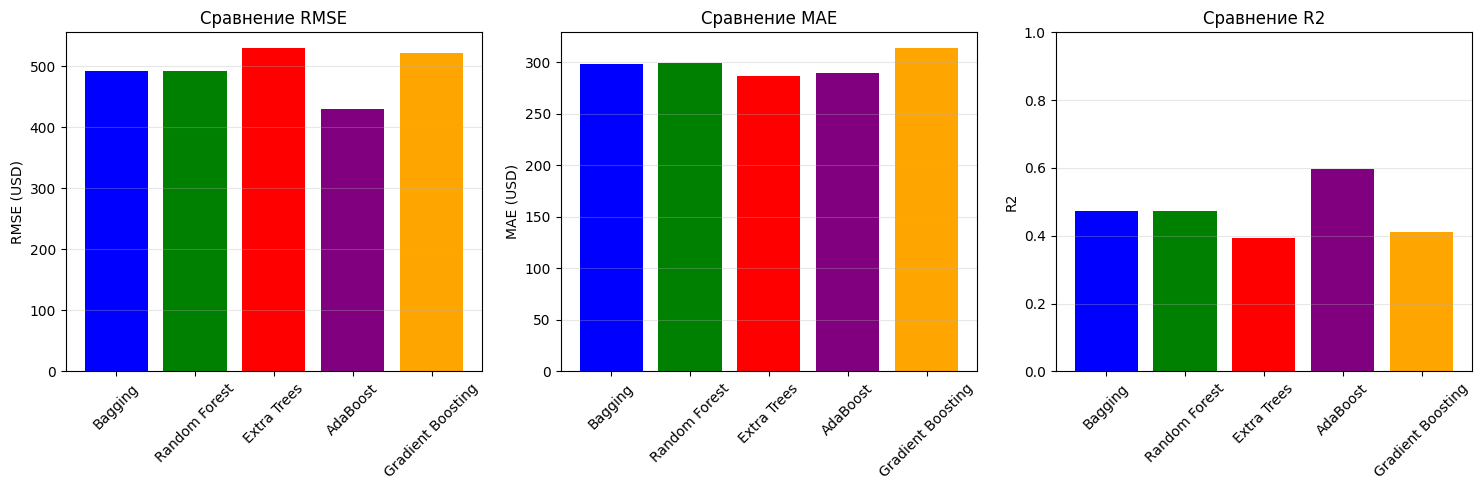

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models_names = results['Модель'].tolist()

axes[0].bar(models_names, results['RMSE (USD)'], color=['blue', 'green', 'red', 'purple', 'orange'])
axes[0].set_ylabel('RMSE (USD)')
axes[0].set_title('Сравнение RMSE')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(models_names, results['MAE (USD)'], color=['blue', 'green', 'red', 'purple', 'orange'])
axes[1].set_ylabel('MAE (USD)')
axes[1].set_title('Сравнение MAE')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

axes[2].bar(models_names, results['R2'], color=['blue', 'green', 'red', 'purple', 'orange'])
axes[2].set_ylabel('R2')
axes[2].set_title('Сравнение R2')
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Важность признаков (Random Forest)

In [15]:
feature_importance = pd.DataFrame({
    'Признак': feature_cols,
    'Важность': rf.feature_importances_
}).sort_values('Важность', ascending=False)

print("ВАЖНОСТЬ ПРИЗНАКОВ (RANDOM FOREST)")
print(feature_importance.head(10))

ВАЖНОСТЬ ПРИЗНАКОВ (RANDOM FOREST)
                Признак  Важность
10             curr_EUR  0.487243
0    Minimum_Wage_Local  0.230898
13             curr_XCD  0.084241
3      currency_encoded  0.037103
4        period_encoded  0.031050
15        period_Hourly  0.030965
19  note_has_collective  0.020070
2      has_minimum_wage  0.018964
1                  Year  0.018236
18   note_has_statutory  0.012762


График важности признаков

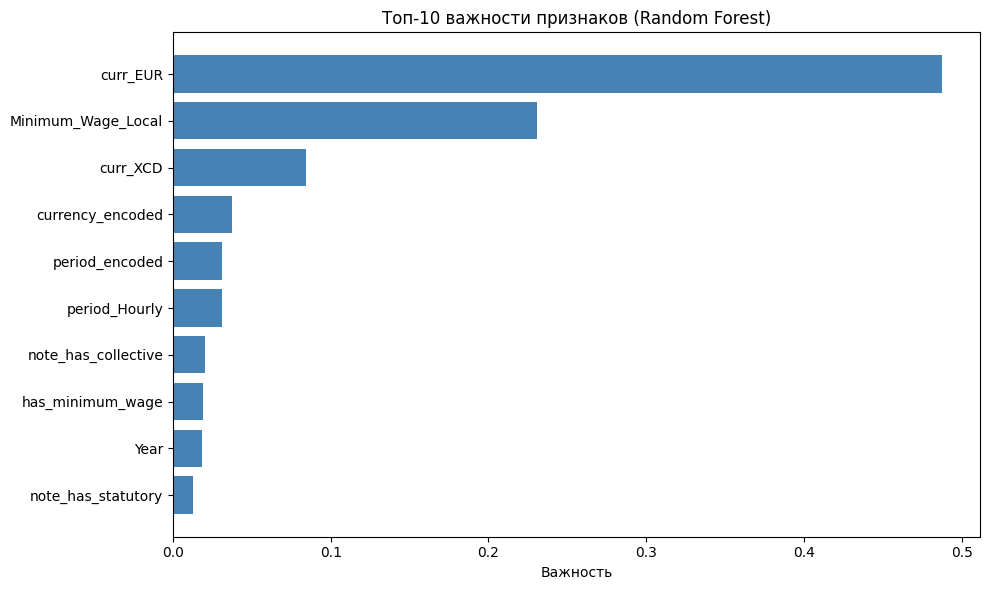

In [16]:
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(top_features['Признак'], top_features['Важность'], color='steelblue')
plt.xlabel('Важность')
plt.title('Топ-10 важности признаков (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Итоговые выводы

In [17]:
print("ВЫВОДЫ ПО РЕЗУЛЬТАТАМ ЛАБОРАТОРНОЙ РАБОТЫ №5")
print(f"1. Bagging: R2={r2_bagging:.3f}, RMSE={rmse_bagging:.1f} USD")
print(f"2. Random Forest: R2={r2_rf:.3f}, RMSE={rmse_rf:.1f} USD")
print(f"3. Extra Trees: R2={r2_et:.3f}, RMSE={rmse_et:.1f} USD")
print(f"4. AdaBoost: R2={r2_ada:.3f}, RMSE={rmse_ada:.1f} USD")
print(f"5. Gradient Boosting: R2={r2_gb:.3f}, RMSE={rmse_gb:.1f} USD")
print(f"\nЛучшая модель: {best_model}")

ВЫВОДЫ ПО РЕЗУЛЬТАТАМ ЛАБОРАТОРНОЙ РАБОТЫ №5
1. Bagging: R2=0.474, RMSE=492.6 USD
2. Random Forest: R2=0.474, RMSE=492.9 USD
3. Extra Trees: R2=0.393, RMSE=529.1 USD
4. AdaBoost: R2=0.598, RMSE=430.6 USD
5. Gradient Boosting: R2=0.411, RMSE=521.3 USD

Лучшая модель: AdaBoost
